## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import shap
import ast

from collections import defaultdict, deque
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, f1_score, confusion_matrix

c:\Users\ACER\miniconda3\envs\mworld\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Feature Engineering
Create Relational features from absolute feature to prevent redundancy between features and make easier model to analize data pattern.

In [44]:
df_matches = pd.read_csv(r"E:\End-to-End-ML-MWorld-Champions\data\interim\matches.csv")
df_matches.head(10)

,match_keys,date,tier_name,tournament_name,stage_name,bracket_name,home_team,away_team,home_score,away_score,winner,score,match_id
0,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,2025-02-28 16:00:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,twisted minds ph,aurora gaming ph,0,2,aurora gaming ph,0-2,1
1,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,2025-02-28 18:30:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,onic philippines,tnc pro team,2,0,onic philippines,2-0,2
2,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,2025-03-01 13:30:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,team falcons ph,team liquid ph,0,2,team liquid ph,0-2,3
3,2025-03-01 16:00:00+07:00_MPL Philippines Seas...,2025-03-01 16:00:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,tnc pro team,ap.bren,2,0,tnc pro team,2-0,4
4,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,aurora gaming ph,onic philippines,2,1,aurora gaming ph,2-1,5
5,2025-03-02 16:00:00+07:00_MPL Philippines Seas...,2025-03-02 16:00:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,omega esports,team falcons ph,0,2,team falcons ph,0-2,6
6,2025-03-02 18:30:00+07:00_MPL Philippines Seas...,2025-03-02 18:30:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,team liquid ph,twisted minds ph,2,0,team liquid ph,2-0,7
7,2025-03-07 15:15:00+07:00_MPL Indonesia Season...,2025-03-07 15:15:00+07:00,A-Tier_Tournaments,MPL Indonesia Season 15,Regular Season,Group Stage,natus vincere,rrq hoshi,0,2,rrq hoshi,0-2,8
8,2025-03-07 16:00:00+07:00_MPL Philippines Seas...,2025-03-07 16:00:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,team falcons ph,onic philippines,2,1,team falcons ph,2-1,9
9,2025-03-07 18:15:00+07:00_MPL Indonesia Season...,2025-03-07 18:15:00+07:00,A-Tier_Tournaments,MPL Indonesia Season 15,Regular Season,Group Stage,evos,team liquid id,2,1,evos,2-1,10


In [95]:
df_games = pd.read_csv(r"E:\End-to-End-ML-MWorld-Champions\data\interim\games.csv")
df_games.head(10)

,date,match_keys,game_keys,tier_name,tournament_name,stage_name,bracket_name,game_num,map_name,duration,...,away_gold_5mnt,home_gold_10mnt,away_gold_10mnt,home_gold_15mnt,away_gold_15mnt,home_gold_20mnt,away_gold_20mnt,game_id,home_score,away_score
0,2025-02-28 18:30:00+07:00,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,17:52,...,-1800.0,4000.0,-4000.0,4800.0,-4800.0,NaN,NaN,1,1,0
1,2025-02-28 18:30:00+07:00,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,21:55,...,67.0,-2700.0,2700.0,-6400.0,6400.0,-6000.0,6000.0,2,1,0
2,2025-02-28 16:00:00+07:00,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,18:52,...,1500.0,-3500.0,3500.0,-8000.0,8000.0,NaN,NaN,3,0,1
3,2025-02-28 16:00:00+07:00,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,13:52,...,1400.0,-7800.0,7800.0,NaN,NaN,NaN,NaN,4,0,1
4,2025-03-01 18:30:00+07:00,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,19:48,...,-1600.0,6900.0,-6900.0,5400.0,-5400.0,NaN,NaN,5,1,0
5,2025-03-01 18:30:00+07:00,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,12:41,...,-540.0,-1000.0,1000.0,NaN,NaN,NaN,NaN,6,0,1
6,2025-03-01 18:30:00+07:00,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,3,default,16:02,...,-153.0,3500.0,-3500.0,2600.0,-2600.0,NaN,NaN,7,1,0
7,2025-03-01 13:30:00+07:00,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,18:34,...,503.0,401.0,-401.0,-3500.0,3500.0,NaN,NaN,8,0,1
8,2025-03-01 13:30:00+07:00,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,12:31,...,1300.0,-8700.0,8700.0,NaN,NaN,NaN,NaN,9,0,1
9,2025-03-01 16:00:00+07:00,2025-03-01 16:00:00+07:00_MPL Philippines Seas...,2025-03-01 16:00:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,13:12,...,-2200.0,8200.0,-8200.0,NaN,NaN,NaN,NaN,10,1,0


Change a list contained feature into wide format

In [96]:
def item_explode(columns):
    team_picks = []
    for i in columns:
        stat = ast.literal_eval(i)
        team_picks.append(stat)
    return team_picks

for team in ["home", "away"]:
    for step in ["picks", "bans"]:
        df_games[team + "_" + step] = item_explode(df_games[team + "_" + step])
        df_games[[
            team + "_" + step + "_" + "1", team + "_" + step + "_" + "2", team + "_" + step + "_" + "3", team + "_" + step + "_" + "4", team + "_" + step + "_" + "5"
        ]] = pd.DataFrame(df_games[team + "_" + step].tolist(), index=df_games.index)

# df_games["home_picks"] = item_explode(df_games["home_picks"])
# df_games[["home_picks_1", "home_picks_2", "home_picks_3", "home_picks_4", "home_picks_5"]] = pd.DataFrame(df_games["home_picks"].tolist(), index=df_games.index)
# df_games["away_picks"] = item_explode(df_games["away_picks"])
# df_games[["away_picks_1", "away_picks_2", "away_picks_3", "away_picks_4", "away_picks_5"]] = pd.DataFrame(df_games["away_picks"].tolist(), index=df_games.index)
# df_games["home_bans"] = item_explode(df_games["home_bans"])
# df_games[["home_bans_1", "home_bans_2", "home_bans_3", "home_bans_4", "home_bans_5"]] = pd.DataFrame(df_games["home_bans"].tolist(), index=df_games.index)
# df_games["away_bans"] = item_explode(df_games["away_bans"])
# df_games[["away_bans_1", "away_bans_2", "away_bans_3", "away_bans_4", "away_bans_5"]] = pd.DataFrame(df_games["away_bans"].tolist(), index=df_games.index)

Display row with NaN values

In [97]:
na_row = df_games.copy()
na_row = na_row.drop(columns=na_row.columns[:-20])
na_row[na_row.isna().any(axis=1)]

,home_picks_1,home_picks_2,home_picks_3,home_picks_4,home_picks_5,home_bans_1,home_bans_2,home_bans_3,home_bans_4,home_bans_5,away_picks_1,away_picks_2,away_picks_3,away_picks_4,away_picks_5,away_bans_1,away_bans_2,away_bans_3,away_bans_4,away_bans_5
117,Badang,Hanzo,Yve,Beatrix,Tigreal,Zhuxin,Mathilda,Luo Yi,Hylos,None,Hilda,Ling,Cecilion,Granger,Khaleed,Gatotkaca,Fanny,Harith,Cici,Joy
140,Phoveus,Suyou,Pharsa,Brody,Jawhead,Zhuxin,Luo Yi,Chip,None,None,Hilda,Fanny,Aurora,Granger,Chou,Mathilda,Harith,Moskov,None,None
600,Hylos,Suyou,Aurora,Irithel,Gatotkaca,Luo Yi,Hanzo,Kalea,Lukas,None,Julian,Fanny,Zhuxin,Clint,Grock,Harith,Mathilda,Chip,Phoveus,None
943,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
973,X.Borg,Fanny,Kimmy,Granger,Chip,Phoveus,Kalea,Badang,Vexana,None,Gloo,Hayabusa,Zhuxin,Irithel,Mathilda,Cecilion,Luo Yi,Lukas,Harith,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2094,Esmeralda,Lancelot,Valentina,Harith,Gatotkaca,Chip,Fanny,Wanwan,None,None,Uranus,Yi Sun-shin,Angela,Bane,Khaleed,Arlott,Cici,Zhuxin,None,None
2185,Ruby,Lancelot,Pharsa,Bruno,Kaja,Kimmy,Yve,Natan,Akai,None,Cici,Lukas,Zetian,Irithel,Khaleed,Angela,Zhuxin,Grock,Lapu-Lapu,X.Borg
2226,Uranus,Baxia,Kimmy,Obsidia,Mathilda,Joy,Esmeralda,Chip,None,None,Cici,Lancelot,Bane,Brody,Gatotkaca,Yve,Lunox,Zhuxin,Kalea,None
2572,Esmeralda,Yi Sun-shin,Pharsa,Harith,Hilda,Grock,Uranus,Arlott,Lapu-Lapu,None,Gloo,Lancelot,Kimmy,Brody,Hylos,Baxia,Zhuxin,Kalea,Gatotkaca,Kaja


In [98]:
df_heroes = pd.read_csv(r"E:\End-to-End-ML-MWorld-Champions\data\interim\heroes.csv")
df_heroes

,hero_name,role_name,hero_id
0,Akai,Tank,1
1,Alice,Tank,2
2,Atlas,Tank,3
3,Barats,Tank,4
4,Baxia,Tank,5
...,...,...,...
163,Lolita,Support,164
164,Marcel,Support,165
165,Mathilda,Support,166
166,Minotaur,Support,167


In [99]:
def kda_score(kill, assist, death):
    if np.nan in death or 0.0 in death:
        kda = kill + assist
        return kda
    
    kda = (kill + assist) / death
    return kda

def scale_score(feature1, feature2):
    if np.nan in feature1 or np.nan in feature2:
        return np.nan
    
    return feature1 / feature2

def diff_score(feature1, feature2):
    return feature1 - feature2
    
def time_converts(time_str):
    if pd.isna(time_str):
        return np.nan
    m, s = map(int, time_str.split(":"))
    duration = m + (s / 60)
    return duration

Create relational features such gold_eff, kda_diff, objective_diff, early_gold_diff, mid_gold_diff, late_gold_diff and comeback flag.

In [100]:
df_games["duration"] = [time_converts(i) for i in df_games["duration"]]
df_games["home_score"] = np.where(df_games["home_status"] == "win", 1, 0)
df_games["away_score"] = np.where(df_games["away_status"] == "win", 1, 0)
df_games["gold_total_diff"] = diff_score(df_games["home_gold_total"], df_games["away_gold_total"])
df_games["gold_eff"] = scale_score(df_games["gold_total_diff"], df_games["duration"])
df_games["objective_diff"] = diff_score(
    df_games["home_turtles"] + df_games["home_lords"] + df_games["home_towers"],
    df_games["away_turtles"] + df_games["away_lords"] + df_games["away_towers"]
)
df_games["kda_diff"] = diff_score(
    kda_score(df_games["home_kills"], df_games["home_assists"], df_games["home_deaths"]),
    kda_score(df_games["away_kills"], df_games["away_assists"], df_games["away_deaths"])
)
df_games["early_gold_diff"] = df_games["home_gold_5mnt"]
df_games["early_eff_diff"] = df_games["home_gold_5mnt"] * df_games["gold_eff"]
df_games["is_mid_game"] = (df_games["duration"] >= 10.0).astype(int)
df_games["mid_gold_diff"] = diff_score(df_games["home_gold_10mnt"], df_games["home_gold_5mnt"])
df_games["mid_eff_diff"] = diff_score(df_games["home_gold_10mnt"], df_games["home_gold_5mnt"]) * df_games["gold_eff"]
df_games["is_late_game"] = (df_games["duration"] >= 15.0).astype(int)
df_games["late_gold_diff"] = diff_score(df_games["home_gold_15mnt"], df_games["home_gold_10mnt"])
df_games["late_eff_diff"] = diff_score(df_games["home_gold_15mnt"], df_games["home_gold_10mnt"]) * df_games["gold_eff"]
df_games["is_very_late_game"] = (df_games["duration"] >= 20.0).astype(int)
df_games["very_late_gold_diff"] = diff_score(df_games["home_gold_20mnt"], df_games["home_gold_15mnt"])
df_games["very_late_eff_diff"] = diff_score(df_games["home_gold_20mnt"], df_games["home_gold_15mnt"]) * df_games["gold_eff"]

In [106]:
pick_rate = {hero:0 for hero in df_heroes["hero_name"]}
ban_rate = {hero:0 for hero in df_heroes["hero_name"]}
early_wr = {hero:0 for hero in df_heroes["hero_name"]}
mid_wr = {hero:0 for hero in df_heroes["hero_name"]}
late_wr = {hero:0 for hero in df_heroes["hero_name"]}

In [107]:
# Calculate Draft intelligence (on progress)
hero_draft_stat = defaultdict(lambda:{
    "win": 0,
    "total": 0
})
hero_stat = defaultdict(lambda:{
    "picks": 0,
    "bans": 0,
    "early_win": 0,
    "early_end_games": 0,
    "mid_win": 0,
    "mid_end_games": 0,
    "late_win": 0,
    "late_end_games": 0,
    "games_total": 0
})
def get_hero_winrate(team, hero):
    if pd.isna(hero):
        return np.nan
    
    key = (team, hero)
    stats = hero_draft_stat[key]
    
    return (stats["win"] + 1) / (stats["total"] + 2)

history = []

for i, row in df_games.iterrows():
    keys = row["match_keys"]
    duration = row["duration"]
    t1, t2 = row["home_team"], row["away_team"]
    st1, st2 = row["home_status"], row["away_status"]
    hp1, ap1 = row["home_picks_1"], row["away_picks_1"]
    hp2, ap2 = row["home_picks_2"], row["away_picks_2"]
    hp3, ap3 = row["home_picks_3"], row["away_picks_3"]
    hp4, ap4 = row["home_picks_4"], row["away_picks_4"]
    hp5, ap5 = row["home_picks_5"], row["away_picks_5"]
    hb1, ab1 = row["home_bans_1"], row["away_bans_1"]
    hb2, ab2 = row["home_bans_2"], row["away_bans_2"]
    hb3, ab3 = row["home_bans_3"], row["away_bans_3"]
    hb4, ab4 = row["home_bans_4"], row["away_bans_4"]
    hb5, ab5 = row["home_bans_5"], row["away_bans_5"]
    
    s1 = 1 if st1 == "win" else 0
    s2 = 1 if st2 == "win" else 0

    for team in [t1, t2]:
        if team == t1:
            home_draft_wr = []
            for phase in ["picks", "bans"]:
                if phase == "bans":
                    for hero in [hb1, hb2, hb3, hb4, hb5]:
                        hero_stat[hero]["bans"] += 1
                        hero_stat[hero]["games_total"] += 1

                        ban_rate[hero] = (hero_stat[hero]["bans"] + 1) / (hero_stat[hero]["games_total"] + 2)
                if phase == "picks":
                    for hero in [hp1, hp2, hp3, hp4, hp5]:
                        hero_wr = get_hero_winrate(team, hero)
                        home_draft_wr.append(hero_wr)
                        
                        hero_draft_stat[(team, hero)]["win"] += s1
                        hero_draft_stat[(team, hero)]["total"] += 1
                        
                        hero_stat[hero]["picks"] += 1
                        hero_stat[hero]["games_total"] += 1
                        hero_stat[hero]["early_win"] += s1 if duration <= 10 else 0
                        hero_stat[hero]["early_end_games"] += 1 if duration <= 10 else 0
                        hero_stat[hero]["mid_win"] += s1 if 10 < duration <= 15 else 0
                        hero_stat[hero]["mid_end_games"] += 1 if 10 < duration <= 15 else 0
                        hero_stat[hero]["late_win"] += s1 if duration > 15 else 0
                        hero_stat[hero]["late_end_games"] += 1 if duration > 15 else 0

                        pick_rate[hero] = (hero_stat[hero]["picks"] + 1) / (hero_stat[hero]["games_total"] + 2)
                        early_wr[hero] = (hero_stat[hero]["early_win"] + 1) / (hero_stat[hero]["early_end_games"] + 2)
                        mid_wr[hero] = (hero_stat[hero]["mid_win"] + 1) / (hero_stat[hero]["mid_end_games"] + 2)
                        late_wr[hero] = (hero_stat[hero]["late_win"] + 1) / (hero_stat[hero]["late_end_games"] + 2)

            home_draft_wr = np.mean(home_draft_wr)
        if team == t2:
            away_draft_wr = []
            away_draft_stability = []
            for phase in ["picks", "bans"]:
                if phase == "bans":
                    for hero in [ab1, ab2, ab3, ab4, ab5]:
                        hero_stat[hero]["bans"] += 1
                        hero_stat[hero]["games_total"] += 1

                        ban_rate[hero] = (hero_stat[hero]["bans"] + 1) / (hero_stat[hero]["games_total"] + 2)
                if phase == "picks":
                    for hero in [ap1, ap2, ap3, ap4, ap5]:
                        hero_wr = get_hero_winrate(team, hero)
                        away_draft_wr.append(hero_wr)
                        
                        hero_draft_stat[(team, hero)]["win"] += s1
                        hero_draft_stat[(team, hero)]["total"] += 1
                        
                        hero_stat[hero]["picks"] += 1
                        hero_stat[hero]["games_total"] += 1
                        hero_stat[hero]["early_win"] += s1 if duration <= 10 else 0
                        hero_stat[hero]["early_end_games"] += 1 if duration <= 10 else 0
                        hero_stat[hero]["mid_win"] += s1 if 10 < duration <= 15 else 0
                        hero_stat[hero]["mid_end_games"] += 1 if 10 < duration <= 15 else 0
                        hero_stat[hero]["late_win"] += s1 if duration > 15 else 0
                        hero_stat[hero]["late_end_games"] += 1 if duration > 15 else 0

                        pick_rate[hero] = (hero_stat[hero]["picks"] + 1) / (hero_stat[hero]["games_total"] + 2)
                        early_wr[hero] = (hero_stat[hero]["early_win"] + 1) / (hero_stat[hero]["early_end_games"] + 2)
                        mid_wr[hero] = (hero_stat[hero]["mid_win"] + 1) / (hero_stat[hero]["mid_end_games"] + 2)
                        late_wr[hero] = (hero_stat[hero]["late_win"] + 1) / (hero_stat[hero]["late_end_games"] + 2)
                        
            away_draft_wr = np.mean(away_draft_wr)

    draft_wr_diff = home_draft_wr - away_draft_wr
    history.append({
        "home_draft_wr": home_draft_wr,
        "away_draft_wr": away_draft_wr,
        "draft_wr_diff": draft_wr_diff
    })

df = pd.DataFrame(history)
df

,home_draft_wr,away_draft_wr,draft_wr_diff
0,0.500000,0.500000,0.000000e+00
1,0.533333,0.500000,3.333333e-02
2,0.500000,0.500000,0.000000e+00
3,0.466667,0.466667,5.551115e-17
4,0.450000,0.533333,-8.333333e-02
...,...,...,...
3370,0.630000,0.597114,3.288600e-02
3371,0.723179,0.589577,1.336019e-01
3372,0.737312,0.587778,1.495338e-01
3373,0.491270,0.509632,-1.836251e-02


In [108]:
# df_games = df_games.drop(columns=df_games.columns[-20:])
df_games["home_draft_wr"] = df["home_draft_wr"].round(2)
df_games["away_draft_wr"] = df["away_draft_wr"].round(2)
df_games["draft_wr_diff"] = df["draft_wr_diff"].round(2)


In [109]:
column_dict = {
    "pick_rate": pick_rate,
    "ban_rate": ban_rate,
    "early_wr": early_wr,
    "mid_wr": mid_wr,
    "late_wr": late_wr
}

for column, dict_ in column_dict.items():
    df = pd.DataFrame.from_dict(dict_, orient="index", columns=[column]).reset_index(names="hero_name")
    df_heroes = df_heroes.merge(df, how="left", on="hero_name")


In [111]:
df_heroes["mid_scaling"] = diff_score(df_heroes["mid_wr"], df_heroes["early_wr"])
df_heroes["late_scaling"] = diff_score(df_heroes["late_wr"], df_heroes["mid_wr"])
df_heroes["hero_performance_tendency"] = diff_score(df_heroes["late_scaling"], df_heroes["mid_scaling"])
df_heroes["duration_performance_stability"] = np.std([df_heroes["early_wr"], df_heroes["mid_wr"], df_heroes["late_wr"]], axis=0)
df_heroes.head()

,hero_name,role_name,hero_id,pick_rate,ban_rate,early_wr,mid_wr,late_wr,mid_scaling,late_scaling,hero_performance_tendency,duration_performance_stability
0,Akai,Tank,1,0.613445,0.388186,0.750000,0.500000,0.545455,-0.250000,0.045455,0.295455,0.108733
1,Alice,Tank,2,0.582255,0.422430,0.833333,0.510345,0.508876,-0.322989,-0.001469,0.321519,0.152606
2,Atlas,Tank,3,0.823529,0.200000,0.500000,0.500000,0.400000,0.000000,-0.100000,-0.100000,0.047140
3,Barats,Tank,4,0.900000,0.333333,0.500000,0.400000,0.454545,-0.100000,0.054545,0.154545,0.040881
4,Baxia,Tank,5,0.312953,0.687403,0.454545,0.570342,0.556886,0.115797,-0.013456,-0.129253,0.051708


In [112]:
hero_tendency_map = (
    df_heroes
    .set_index("hero_name")["hero_performance_tendency"]
    .to_dict()
)

hero_stability_map = (
    df_heroes
    .set_index("hero_name")["duration_performance_stability"]
    .to_dict()
)

for col in ["home_picks_1", "home_picks_2", "home_picks_3", "home_picks_4", "home_picks_5", "away_picks_1", "away_picks_2", "away_picks_3", "away_picks_4", "away_picks_5"]:
    df_games[f"{col}_tendency"] = df_games[col].map(hero_tendency_map)
    df_games[f"{col}_stability"] = df_games[col].map(hero_stability_map)

df_games["home_draft_tendency"] = (df_games["home_picks_1_tendency"] + df_games["home_picks_2_tendency"] + df_games["home_picks_3_tendency"] + df_games["home_picks_4_tendency"] + df_games["home_picks_5_tendency"]) / 5
df_games["away_draft_tendency"] = (df_games["away_picks_1_tendency"] + df_games["away_picks_2_tendency"] + df_games["away_picks_3_tendency"] + df_games["away_picks_4_tendency"] + df_games["away_picks_5_tendency"]) / 5
df_games["home_draft_stability"] = (df_games["home_picks_1_stability"] + df_games["home_picks_2_stability"] + df_games["home_picks_3_stability"] + df_games["home_picks_4_stability"] + df_games["home_picks_5_stability"]) / 5
df_games["away_draft_stability"] = (df_games["away_picks_1_stability"] + df_games["away_picks_2_stability"] + df_games["away_picks_3_stability"] + df_games["away_picks_4_stability"] + df_games["away_picks_5_stability"]) / 5
df_games["draft_tendency_diff"] = diff_score(df_games["home_draft_tendency"], df_games["away_draft_tendency"])
df_games["draft_stability_diff"] = diff_score(df_games["home_draft_stability"], df_games["away_draft_stability"])

Aggregation games based dataset into match based dataset

In [125]:
match_stat_avg = df_games.groupby(["match_keys"]).agg(
    duration=("duration", "mean"),
    home_team=("home_team", "first"),
    away_team=("away_team", "first"),
    home_draft_wr=("home_draft_wr", "mean"),
    away_draft_wr=("away_draft_wr", "mean"),
    draft_wr_diff=("draft_wr_diff", "mean"),
    draft_tendency_diff=("draft_tendency_diff", "mean"),
    draft_stability_diff=("draft_stability_diff", "mean"),
    gold_total_diff=("gold_total_diff", "mean"),
    gold_eff=("gold_eff", "mean"),
    objective_diff=("objective_diff", "mean"),
    kda_diff=("kda_diff", "mean"),
    # early_gold_diff=("early_gold_diff", "mean"),
    early_eff_diff=("early_eff_diff", "mean"),
    is_mid_game=("is_mid_game", "mean"),
    # mid_gold_diff=("mid_gold_diff", "mean"),
    mid_eff_diff=("mid_eff_diff", "mean"),
    is_late_game=("is_late_game", "mean"),
    # late_gold_diff=("late_gold_diff", "mean"),
    late_eff_diff=("late_eff_diff", "mean"),
    is_very_late_game=("is_very_late_game", "mean"),
    # very_late_gold_diff=("very_late_gold_diff", "mean"),
    very_late_eff_diff=("very_late_eff_diff", "mean")
    # home_is_comeback=("home_is_comeback", "sum"),
    # home_behind_any_phase=("home_behind_any_phase", "sum"),
    # away_is_comeback=("away_is_comeback", "sum"),
    # away_behind_any_phase=("away_behind_any_phase", "sum")
).reset_index()
for col in match_stat_avg.columns:
    if match_stat_avg[col].dtype == float:
        match_stat_avg[col] = match_stat_avg[col].round(2)
match_stat_avg

,match_keys,duration,home_team,away_team,home_draft_wr,away_draft_wr,draft_wr_diff,draft_tendency_diff,draft_stability_diff,gold_total_diff,gold_eff,objective_diff,kda_diff,early_eff_diff,is_mid_game,mid_eff_diff,is_late_game,late_eff_diff,is_very_late_game,very_late_eff_diff
0,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,16.37,twisted minds ph,aurora gaming ph,0.48,0.48,0.00,0.07,0.01,-11050.00,-709.92,-10.00,-27.50,1017999.12,1.0,3482332.16,0.50,2170494.70,0.00,NaN
1,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,19.89,onic philippines,tnc pro team,0.52,0.50,0.02,-0.04,-0.01,4900.00,258.74,0.00,3.50,337951.76,1.0,238451.39,1.00,-100993.13,0.50,54752.85
2,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,15.54,team falcons ph,team liquid ph,0.48,0.50,-0.02,-0.06,0.01,-9500.00,-673.08,-9.50,-27.00,733343.57,1.0,3504837.60,0.50,1386710.95,0.00,NaN
3,2025-03-01 16:00:00+07:00_MPL Philippines Seas...,12.18,tnc pro team,ap.bren,0.57,0.55,0.02,0.02,-0.01,8550.00,692.99,9.50,40.50,1466292.97,1.0,4012229.92,0.00,NaN,0.00,NaN
4,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,16.17,aurora gaming ph,onic philippines,0.41,0.58,-0.16,0.03,0.00,900.00,5.37,3.33,6.67,71554.77,1.0,895327.50,0.67,-281169.28,0.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1280,2025-12-21 20:45:00+07:00_Games of the Future ...,18.97,onic,team falcons,0.59,0.58,0.01,-0.01,0.00,6400.00,388.36,6.00,21.67,398626.88,1.0,1106758.23,1.00,2542216.91,0.33,-107012.20
1281,2025-12-22 18:00:00+07:00_Games of the Future ...,17.41,dianfengyaoguai,aurora gaming,0.53,0.69,-0.17,0.10,-0.01,-6566.67,-453.23,-7.33,-46.67,667297.51,1.0,1874815.30,1.00,2515143.30,0.33,79210.93
1282,2025-12-22 20:00:00+07:00_Games of the Future ...,16.39,aurora gaming ph,onic,0.51,0.60,-0.10,0.00,0.01,-10200.00,-667.49,-9.00,-36.50,784541.90,1.0,1872774.49,0.50,2125834.80,0.00,NaN
1283,2025-12-23 18:00:00+07:00_Games of the Future ...,17.90,dianfengyaoguai,aurora gaming ph,0.44,0.61,-0.16,-0.07,0.01,-11750.00,-659.42,-8.00,-64.00,1135983.89,1.0,1236553.23,0.50,3745648.85,0.50,452061.07


In [126]:
df_games["bracket_name"].unique()

array(['Group Stage', 'Quarterfinals', 'Semifinals', 'Grand Final',
       'Upper Bracket Quaterfinals', 'Upper Bracket Semifinals',
       'Upper Bracket Final', 'Lower Bracket Final',
       'Lower Bracket Semifinal', 'Upper Bracket Quarterfinals',
       'Lower Bracket Quarterfinals', 'Lower Bracket Round 1', 'Final',
       'Finals', 'Upper Bracket Seminfinals', 'Lower Bracket Semifinals',
       'Upper Bracket Quartefinals', 'Third Place Match',
       'Upper Bracket Round 1', 'Play-In', 'Lower Bracket Quaterfinals',
       'Play-Ins', 'Third Place'], dtype=object)

In [127]:
# # Update soon
# # Weight feature for pressure score
# tier_map = {
#     "S-Tier_Tournaments": 1.6,
#     "A-Tier_Tournaments": 1.4,
#     "B-Tier_Tournaments": 1.2,
#     "Qualifier_Tournaments": 1.0,
# }
# stage_map= {
#     "Playoffs": 1.6,
#     "Regular Season": 1.4,
#     "Group Stage": 1.4,
#     "Stage 2": 1.4,
#     "Play-In": 1.2,
#     "Play-Ins": 1.2,
#     "wildcard Playoffs": 1.2,
#     "Wildcard Group Stage": 1.0,
#     "Last Chance Qualifier": 1.0,
#     "Last Chance": 1.0,
#     "Challenger": 1.0,
# }
# bracket_map = {
#     "Grand Final": ,
#     "Third Place Match",
#     "Third Place",
#     "Final",
#     "Finals",
#     "Upper Bracket Final",
#     "Lower Bracket Final",
#     "Group Stage",
#     "Quarterfinals",
#     "Semifinals",
#     "Upper Bracket Semifinals",
#     "Lower Bracket Semifinal",
#     "Upper Bracket Seminfinals",
#     "Lower Bracket Semifinals",
#     "Upper Bracket Quarterfinals",
#     "Upper Bracket Quaterfinals",
#     "Upper Bracket Quartefinals",
#     "Lower Bracket Quarterfinals",
#     "Lower Bracket Quaterfinals",
#     "Upper Bracket Round 1": 0.6,
#     "Lower Bracket Round 1": 0.6,
#     "Play-In": 0.6,
#     "Play-Ins": 0.6,
# }

Merging statitistic score dataset and match statistic from aggregation into a single dataset.

In [128]:
matches_cleaned = df_matches.merge(match_stat_avg, how="left", on="match_keys")
matches_cleaned = matches_cleaned.drop(columns=["home_team_y", "away_team_y"]).rename(columns={
    "home_team_x": "home_team", "away_team_x": "away_team"
})
matches_cleaned

,match_keys,date,tier_name,tournament_name,stage_name,bracket_name,home_team,away_team,home_score,away_score,...,gold_eff,objective_diff,kda_diff,early_eff_diff,is_mid_game,mid_eff_diff,is_late_game,late_eff_diff,is_very_late_game,very_late_eff_diff
0,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,2025-02-28 16:00:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,twisted minds ph,aurora gaming ph,0,2,...,-709.92,-10.00,-27.50,1017999.12,1.0,3482332.16,0.50,2170494.70,0.00,NaN
1,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,2025-02-28 18:30:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,onic philippines,tnc pro team,2,0,...,258.74,0.00,3.50,337951.76,1.0,238451.39,1.00,-100993.13,0.50,54752.85
2,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,2025-03-01 13:30:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,team falcons ph,team liquid ph,0,2,...,-673.08,-9.50,-27.00,733343.57,1.0,3504837.60,0.50,1386710.95,0.00,NaN
3,2025-03-01 16:00:00+07:00_MPL Philippines Seas...,2025-03-01 16:00:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,tnc pro team,ap.bren,2,0,...,692.99,9.50,40.50,1466292.97,1.0,4012229.92,0.00,NaN,0.00,NaN
4,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,aurora gaming ph,onic philippines,2,1,...,5.37,3.33,6.67,71554.77,1.0,895327.50,0.67,-281169.28,0.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1280,2025-12-21 20:45:00+07:00_Games of the Future ...,2025-12-21 20:45:00+07:00,A-Tier_Tournaments,Games of the Future 2025,Playoffs,Quarterfinals,onic,team falcons,2,1,...,388.36,6.00,21.67,398626.88,1.0,1106758.23,1.00,2542216.91,0.33,-107012.20
1281,2025-12-22 18:00:00+07:00_Games of the Future ...,2025-12-22 18:00:00+07:00,A-Tier_Tournaments,Games of the Future 2025,Playoffs,Semifinals,dianfengyaoguai,aurora gaming,1,2,...,-453.23,-7.33,-46.67,667297.51,1.0,1874815.30,1.00,2515143.30,0.33,79210.93
1282,2025-12-22 20:00:00+07:00_Games of the Future ...,2025-12-22 20:00:00+07:00,A-Tier_Tournaments,Games of the Future 2025,Playoffs,Semifinals,aurora gaming ph,onic,0,2,...,-667.49,-9.00,-36.50,784541.90,1.0,1872774.49,0.50,2125834.80,0.00,NaN
1283,2025-12-23 18:00:00+07:00_Games of the Future ...,2025-12-23 18:00:00+07:00,A-Tier_Tournaments,Games of the Future 2025,Playoffs,Third Place,dianfengyaoguai,aurora gaming ph,0,2,...,-659.42,-8.00,-64.00,1135983.89,1.0,1236553.23,0.50,3745648.85,0.50,452061.07


### Creating elo features and historical statistic data dataset for prediction 
Load team dataset and define 1500 as default elo values for each team. then calculate elo use elo formula. You can explore elo formula on wikipedia.

In [129]:
df_teams = pd.read_csv(r"E:\End-to-End-ML-MWorld-Champions\data\interim\teams.csv")
df_teams

,team_name,team_region,team_id
0,rrq hoshi,Indonesia,1
1,onic,Indonesia,2
2,s8ul esports,India,3
3,team liquid ph,Philippines,4
4,selangor red giants,Malaysia,5
...,...,...,...
159,ra'ad,MENA,160
160,violance,Turkey,161
161,papara supermassive,Turkey,162
162,bad idea right,Turkey,163


In [130]:
region = dict(zip(df_teams["team_name"], df_teams["team_region"]))
region

{'rrq hoshi': 'Indonesia',
 'onic': 'Indonesia',
 's8ul esports': 'India',
 'team liquid ph': 'Philippines',
 'selangor red giants': 'Malaysia',
 'influence rage': 'Latin America',
 'homebois': 'Malaysia',
 'legion esports': 'Vietnam',
 'onic philippines': 'Indonesia',
 'team spirit': 'CIS',
 'cfu gaming': 'Cambodia',
 'virtus.pro': 'CIS',
 'ultra legends': 'MENA',
 'zeta division': 'Japan',
 'mythic seal': 'Myanmar',
 'team falcons': 'MENA',
 'area 77': 'North America',
 'team flash': 'Malaysia',
 'dianfengyaoguai': 'China',
 'aurora gaming': 'Turkey',
 'corinthians': 'Latin America',
 'rare atom': 'China',
 'the mongolz': 'Mongolia',
 'niightmare esports': 'Laos',
 'llg open sesame': 'Japan',
 'inari perfection': 'Japan',
 'u2 esports': 'Japan',
 'yg': 'China',
 'xty': 'China',
 'tidal legends gaming': 'China',
 'ybingame': 'China',
 'the young gaming': 'China',
 'keepbest gaming': 'China',
 'ying jiang nan': 'China',
 'gdy': 'China',
 'guangzhou gaming': 'China',
 'invictus gaming':

In [131]:
elo = {team: 1500 for team in df_teams["team_name"]}
region_winrate = {r: 0 for r in df_teams["team_region"].unique()}
region_momentum = {r: 0 for r in df_teams["team_region"].unique()}

In [133]:
def expected_score(t1, t2):
    return 1 / (1 + 10**((t1-t2)/400))

def diff_score(feature1, feature2):
    return feature1 - feature2

def mean_feature(result):
    return np.nanmean(result) if len(result) > 0 else 0.5

def winrate_last_n(result):
    return np.nanmean(result) if len(result) > 0 else 0.5

def momentum(result):
    if len(result) < 2 :
        return 0

    result = list(result)
    mid = len(result) // 2
    return np.nanmean(result[mid:]) - np.nanmean(result[:mid]) if len(result[:mid]) > 0 or len(result[mid:]) > 0 else 0


team_stat = defaultdict(lambda: {
    "result": deque(maxlen=5),
    "draft_wr": deque(maxlen=5),
    "scaling_diff": deque(maxlen=5),
    "objective_diff": deque(maxlen=5),
    "kda_diff": deque(maxlen=5),
    "gold_total_diff": deque(maxlen=5),
    "early_eff_diff": deque(maxlen=5),
    "is_mid": deque(maxlen=5),
    "mid_eff_diff": deque(maxlen=5),
    "is_late": deque(maxlen=5),
    "late_eff_diff": deque(maxlen=5),
    "is_very_late": deque(maxlen=5),
    "very_late_eff_diff": deque(maxlen=5),
    "momentum_diff": deque(maxlen=5),
    "comeback_rate_diff": deque(maxlen=5)
})

history = []

k = 32
alpha = 2
beta = 0.01

for i, row in matches_cleaned.iterrows():
    keys = row["match_keys"]
    t1, t2 = row["home_team"], row["away_team"]
    duration = row["duration"]
    home_draft_wr = row["home_draft_wr"]
    away_draft_wr = row["away_draft_wr"]
    draft_wr_diff = row["draft_wr_diff"]
    draft_tendency_diff = row["draft_tendency_diff"]
    draft_stability_diff = row["draft_stability_diff"]
    gold_eff = row["gold_eff"]
    gold_total_diff = row["gold_total_diff"]
    early_eff_diff = row["early_eff_diff"]
    is_mid_game = row["is_mid_game"]
    mid_eff_diff = row["mid_eff_diff"]
    is_late_game = row["is_late_game"]
    late_eff_diff = row["late_eff_diff"]
    is_very_late_game = row["is_very_late_game"]
    very_late_eff_diff = row["very_late_eff_diff"]
    kda_diff = row["kda_diff"]
    objective_diff = row["objective_diff"]
    # comeback_rate_diff = row["comeback_rate_diff"]
    sc1, sc2 = row["home_score"], row["away_score"]
    winner = row["winner"]
    
    ts1, ts2 = team_stat[t1], team_stat[t2]
    r1, r2 = elo[t1], elo[t2]
    
    # Elo Calculation
    elo_diff = diff_score(r1, r2)

    exp1 = expected_score(r1, r2)
    exp2 = expected_score(r2, r1)

    s1 = 1 if winner == t1 else 0.5 if winner == "tie" else 0
    s2 = 1 if winner == t2 else 0.5 if winner == "tie" else 0

    elo[t1] += k * (s1 - exp1)
    elo[t2] += k * (s2 - exp2)

    # Draft winrate
    draft_wr_diff_ = diff_score(mean_feature(ts1["draft_wr"]), mean_feature(ts2["draft_wr"]))
    draft_wr1 = home_draft_wr
    draft_wr2 = away_draft_wr

    # KDA diff
    kda_diff_ = diff_score(mean_feature(ts1["kda_diff"]), mean_feature(ts2["kda_diff"]))
    kda1 = kda_diff
    kda2 = -kda_diff

    # Objective diff
    obj_diff = diff_score(mean_feature(ts1["objective_diff"]), mean_feature(ts2["objective_diff"]))
    obj1 = objective_diff
    obj2 = -objective_diff

    # Scaling diff
    scaling_diff_ = diff_score(mean_feature(ts1["scaling_diff"]), mean_feature(ts2["scaling_diff"]))
    scaling1 = gold_eff
    scaling2 = -gold_eff

    # Gold total diff
    g_diff = diff_score(mean_feature(ts1["gold_total_diff"]), mean_feature(ts2["gold_total_diff"]))
    g_diff1 = gold_total_diff
    g_diff2 = -gold_total_diff

    # Early gold diff
    early_diff = diff_score(mean_feature(ts1["early_eff_diff"]), mean_feature(ts2["early_eff_diff"]))
    early_diff1 = early_eff_diff
    early_diff2 = -early_eff_diff

    # Is mid game
    is_mid = diff_score(mean_feature(ts1["is_mid"]), mean_feature(ts2["is_mid"]))

    # Mid gold diff
    mid_diff = diff_score(mean_feature(ts1["mid_eff_diff"]), mean_feature(ts2["mid_eff_diff"]))
    mid_diff1 = mid_eff_diff
    mid_diff2 = -mid_eff_diff

    # Is late game
    is_late = diff_score(mean_feature(ts1["is_late"]), mean_feature(ts2["is_late"]))

    # Late gold diff
    late_diff = diff_score(mean_feature(ts1["late_eff_diff"]), mean_feature(ts2["late_eff_diff"]))
    late_diff1 = late_eff_diff
    late_diff2 = -late_eff_diff

    # Is very late game
    is_very_late = diff_score(mean_feature(ts1["is_very_late"]), mean_feature(ts2["is_very_late"]))

    # Very late gold diff
    very_late_diff = diff_score(mean_feature(ts1["very_late_eff_diff"]), mean_feature(ts2["very_late_eff_diff"]))
    very_late_diff1 = very_late_eff_diff
    very_late_diff2 = -very_late_eff_diff

    # # Comeback rate diff
    # comeback_rate_diff_ = diff_score(mean_feature(ts1["comeback_rate_diff"]), mean_feature(ts2["comeback_rate_diff"]))
    # comeback_rate_diff1 = comeback_rate_diff
    # comeback_rate_diff2 = -comeback_rate_diff

    # last 5 match winrate difference calculation
    hist_t1, hist_t2  = ts1["result"], ts2["result"]

    wr1 = winrate_last_n(hist_t1)
    wr2 = winrate_last_n(hist_t2)

    winrate_diff = diff_score(wr1, wr2)

    # last 5 match momentum difference calculation

    mom_t1 = momentum(hist_t1)
    mom_t2 = momentum(hist_t2)

    momentum_diff = diff_score(mom_t1, mom_t2)
    
    history.append({
        "match_keys": keys,
        "label": 1 if winner == t1 else 0 if winner == t2 else 0.5,
        "home_team": t1,
        "away_team": t2,
        "duration": duration,
        "draft_wr_diff": draft_wr_diff_,
        "draft_tendency_diff": draft_tendency_diff,
        "draft_stability_diff": draft_stability_diff,
        "elo_diff": elo_diff,
        "kda_diff": kda_diff_,
        "objective_diff": obj_diff,
        "gold_total_diff": g_diff,
        "early_eff_diff": early_diff,
        "is_mid_rate_diff": is_mid,
        "mid_eff_diff": mid_diff,
        "is_late_rate_diff": is_late,
        "late_eff_diff": late_diff,
        "is_very_late_rate_diff": is_very_late,
        "very_late_eff_diff": very_late_diff,
        "winrate_diff": winrate_diff,
        "momentum_diff": momentum_diff,
        "scaling_diff": scaling_diff_,
        # "comeback_rate_diff": comeback_rate_diff_
    })

    # Update team 1
    team_stat[t1]["kda_diff"].append(kda1)
    team_stat[t1]["draft_wr"].append(draft_wr1)
    team_stat[t1]["gold_total_diff"].append(g_diff1)
    team_stat[t1]["objective_diff"].append(obj1)
    team_stat[t1]["scaling_diff"].append(scaling1)
    team_stat[t1]["early_eff_diff"].append(early_diff1)
    team_stat[t1]["is_mid"].append(is_mid_game)
    team_stat[t1]["mid_eff_diff"].append(mid_diff1)
    team_stat[t1]["is_late"].append(is_late_game)
    team_stat[t1]["late_eff_diff"].append(late_diff)
    team_stat[t1]["is_very_late"].append(is_very_late_game)
    team_stat[t1]["very_late_eff_diff"].append(very_late_diff1)
    team_stat[t1]["momentum_diff"].append(mom_t1)
    # team_stat[t1]["comeback_rate_diff"].append(comeback_rate_diff1)
    team_stat[t1]["result"].append(s1)

    # Update team 2
    team_stat[t2]["kda_diff"].append(kda2)
    team_stat[t2]["draft_wr"].append(draft_wr2)
    team_stat[t2]["gold_total_diff"].append(g_diff2)
    team_stat[t2]["objective_diff"].append(obj2)
    team_stat[t2]["scaling_diff"].append(scaling2)
    team_stat[t2]["early_eff_diff"].append(early_diff2)
    team_stat[t2]["is_mid"].append(is_mid_game)
    team_stat[t2]["mid_eff_diff"].append(mid_diff2)
    team_stat[t2]["is_late"].append(is_late_game)
    team_stat[t2]["late_eff_diff"].append(late_diff2)
    team_stat[t2]["is_very_late"].append(is_very_late_game)
    team_stat[t2]["very_late_eff_diff"].append(very_late_diff2)
    team_stat[t2]["momentum_diff"].append(mom_t2)
    # team_stat[t2]["comeback_rate_diff"].append(comeback_rate_diff2)
    team_stat[t2]["result"].append(s2)

C:\Users\ACER\AppData\Local\Temp\ipykernel_18228\298325370.py:8: RuntimeWarning: Mean of empty slice
  return np.nanmean(result) if len(result) > 0 else 0.5


In [134]:
elo = pd.DataFrame.from_dict(elo, orient='index', columns=["elo"]).reset_index(names="team_name")
df_teams = df_teams.merge(elo, on="team_name", how="left")
df_teams.sort_values(by="elo", ascending=False)

,team_name,team_region,team_id,elo
9,team spirit,CIS,10,2215.769215
8,onic philippines,Indonesia,9,2185.077246
0,rrq hoshi,Indonesia,1,2162.040774
3,team liquid ph,Philippines,4,2156.207894
73,aurora gaming ph,Philippines,74,2114.228759
...,...,...,...,...
128,ap.bren,Philippines,129,1101.711359
131,omega esports,Philippines,132,1095.767674
132,twisted minds ph,Philippines,133,1061.769387
94,ombra esports,CIS,95,918.259974


create missing flag for missing values contained in feature

In [135]:
df_final = pd.DataFrame(history)
for col in ["duration", "draft_wr_diff", "draft_tendency_diff", "draft_stability_diff", "kda_diff", "objective_diff", "scaling_diff", "gold_total_diff", "early_eff_diff", "mid_eff_diff", "late_eff_diff", "very_late_eff_diff"]:
    df_final[col] = pd.to_numeric(df_final[col], errors="coerce")
    df_final[col + "_missing"] = df_final[col].isna().astype(int)
    df_final[col] = df_final[col].fillna(0)
# df_final.to_csv(r"E:\End-to-End-MLOps-MWorld-Champions\data\processed\matches_stat.csv")
df_final.columns

Index(['match_keys', 'label', 'home_team', 'away_team', 'duration',
       'draft_wr_diff', 'draft_tendency_diff', 'draft_stability_diff',
       'elo_diff', 'kda_diff', 'objective_diff', 'gold_total_diff',
       'early_eff_diff', 'is_mid_rate_diff', 'mid_eff_diff',
       'is_late_rate_diff', 'late_eff_diff', 'is_very_late_rate_diff',
       'very_late_eff_diff', 'winrate_diff', 'momentum_diff', 'scaling_diff',
       'duration_missing', 'draft_wr_diff_missing',
       'draft_tendency_diff_missing', 'draft_stability_diff_missing',
       'kda_diff_missing', 'objective_diff_missing', 'scaling_diff_missing',
       'gold_total_diff_missing', 'early_eff_diff_missing',
       'mid_eff_diff_missing', 'late_eff_diff_missing',
       'very_late_eff_diff_missing'],
      dtype='object')

Checking feature correlation

In [136]:
numerical_feature = df_final.select_dtypes(include=np.number).drop(columns="label")
vif_data = pd.DataFrame()
vif_data["feature"] = numerical_feature.columns
vif_data["score"] = [variance_inflation_factor(numerical_feature.values, i) for i in range(numerical_feature.shape[1])]
vif_data

c:\Users\ACER\miniconda3\envs\mworld\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,score
0,duration,1.511050
1,draft_wr_diff,1.137897
2,draft_tendency_diff,1.032334
3,draft_stability_diff,1.046466
4,elo_diff,1.299926
5,kda_diff,5.066794
6,objective_diff,6.755469
7,gold_total_diff,53.587211
8,early_eff_diff,3.245959
9,is_mid_rate_diff,1.436823


17 4 7 2 6 5 1 3
["draft_wr_diff", "draft_tendency_diff", "draft_stability_diff", "elo_diff", "kda_diff", "objective_div", "gold_total_diff", "scaling_diff"]
17 7 4 6 2 9 5 1
["draft_wr_diff", "draft_tendency_diff", "elo_diff", "kda_diff", "objective_div", "gold_total_diff", "is_mid_rate_diff", "scaling_diff"]

### Insight
- Scaling_diff and gold_total_diff is highly correlated indicated those feature value already represented by another features. So, dropping both are recommended.
- Most of missing flag variable have infinity score that indicates multicollinearity. Dropping those flag are recommended.

In [148]:
numerical_feature = numerical_feature.drop(columns=numerical_feature.columns[18:])
numerical_feature

,duration,draft_wr_diff,draft_tendency_diff,draft_stability_diff,elo_diff,kda_diff,objective_diff,gold_total_diff,early_eff_diff,is_mid_rate_diff,mid_eff_diff,is_late_rate_diff,late_eff_diff,is_very_late_rate_diff,very_late_eff_diff,winrate_diff,momentum_diff,scaling_diff
0,16.37,0.000,0.07,0.01,-32.000000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000000e+00,0.000,0.000000,0.0,0.000000,0.000
1,19.89,0.000,-0.04,-0.01,0.000000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000000e+00,0.000,0.000000,0.0,0.000000,0.000
2,15.54,0.000,-0.06,0.01,0.000000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000000e+00,0.000,0.000000,0.0,0.000000,0.000
3,12.18,0.000,0.02,-0.01,-16.000000,-4.000,-0.500,-4900.500,-337952.260,0.5,-238451.890,0.500,1.009926e+05,0.000,-54753.350000,-0.5,0.000000,-259.240
4,16.17,-0.040,0.03,0.00,17.469502,24.000,10.000,6150.000,-1355950.880,0.0,-3720783.550,-0.500,-2.170495e+06,-0.500,0.000000,0.0,0.000000,451.180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1280,18.97,-0.006,-0.01,0.00,507.444564,-1.100,0.738,2548.332,792305.418,0.0,2021345.574,-0.094,-1.056470e+06,0.110,253917.547500,0.2,0.333333,209.430
1281,17.41,-0.228,0.10,-0.01,-233.934627,-36.544,-4.778,-6885.998,-377588.836,0.0,-1693071.280,0.050,-2.675700e+06,0.106,-774059.280000,-0.2,-0.333333,-457.844
1282,16.39,-0.094,0.00,0.01,58.497868,-5.238,0.476,-1729.666,-18130.494,0.0,316579.704,-0.006,1.236575e+06,-0.152,-428738.540000,-0.2,0.500000,-106.146
1283,17.90,0.024,-0.07,0.01,-305.077250,-13.852,-2.316,-1571.666,-756680.922,0.0,-1460157.406,-0.084,-1.476573e+06,0.214,931065.982500,0.0,0.000000,-120.994


## Feature Selection and Modeling
Experiment with all feature and model then evaluate for seeking importance feature using model coef and SHAP Analysis for final training. At the end, using selected feature to train model and make a prediction then do error analysis and segment analysis to know better about the model itself works.

Feature Coefficient:
 [[-0.06035108  0.14034654 -0.26033395 -0.1403141   0.29984991  0.20171671
   0.27514497 -0.38534567  0.02900877  0.23789393 -0.00800874 -0.05381608
   0.1193372  -0.04349524 -0.06480159  0.08852262  0.029155    0.48358593]]
Accuracy Score: 0.669260700389105.
Loss Score: 0.6045156731919602.
ROC-AUC Score: 0.7273334953816237.
Matrix Confusion: [[78 43]
 [42 94]].
f1 Score: 0.6886446886446886.


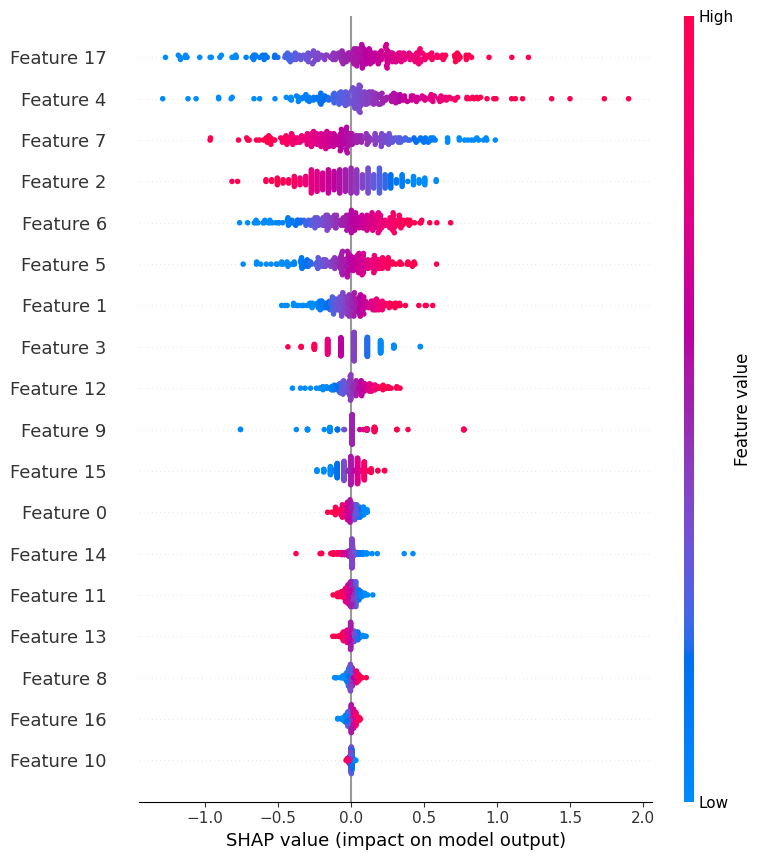

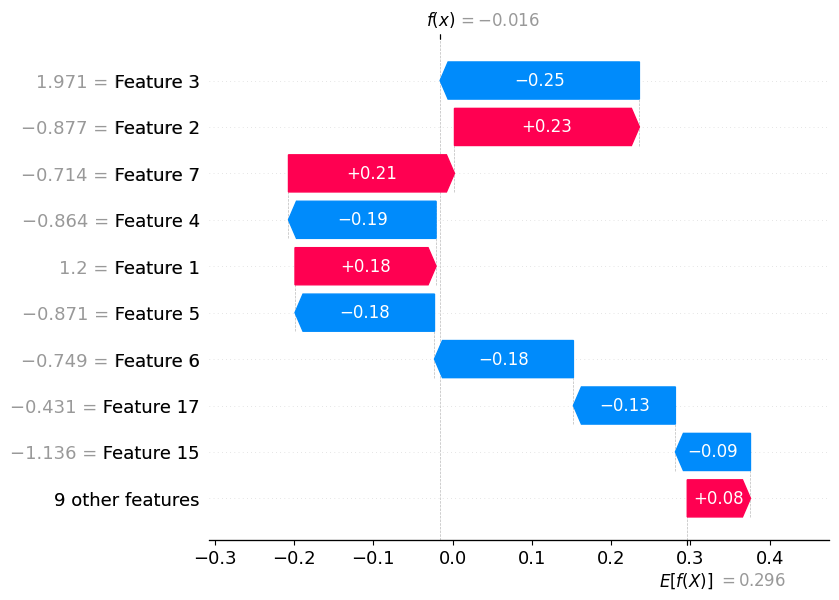

In [ ]:
X = numerical_feature
y = df_final["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_scaled, y_train)

y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
y_pred = (y_pred_proba > 0.6).astype(int)

print("Feature Coefficient:\n", model.coef_)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}.")
print(f"Loss Score: {log_loss(y_test, y_pred_proba)}.")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba)}.")
print(f"Matrix Confusion: {confusion_matrix(y_test, y_pred)}.")
print(f"f1 Score: {f1_score(y_test, y_pred)}.")

explainer = shap.LinearExplainer(model, X_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled)
shap.plots.waterfall(shap_values[0])

**Best 8 High Coef Feature**

Feature Coefficient:
 [[ 0.17426168 -0.24110107  0.27594174  0.20530629  0.35482482 -0.23482515
   0.22799859  0.3428853 ]]
Accuracy Score: 0.642023346303502.
Loss Score: 0.6034174936071015.
ROC-AUC Score: 0.7284273213417598.
Matrix Confusion: [[76 45]
 [47 89]].
f1 Score: 0.6592592592592592.


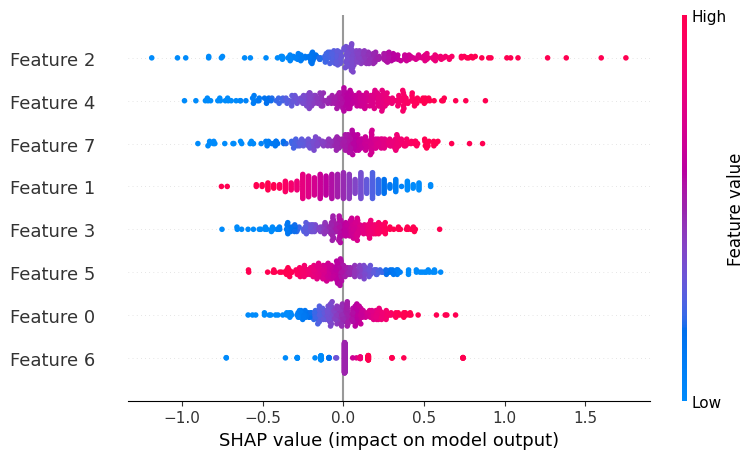

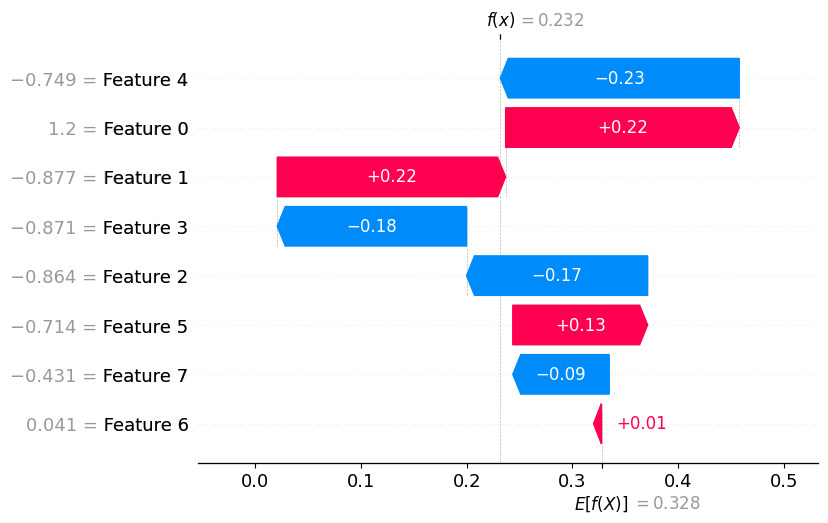

In [160]:
X = numerical_feature[["draft_wr_diff", "draft_tendency_diff", "elo_diff", "kda_diff", "objective_diff", "gold_total_diff", "is_mid_rate_diff", "scaling_diff"]]
y = df_final["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_scaled, y_train)

y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
y_pred = (y_pred_proba > 0.6).astype(int)

print("Feature Coefficient:\n", model.coef_)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}.")
print(f"Loss Score: {log_loss(y_test, y_pred_proba)}.")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba)}.")
print(f"Matrix Confusion: {confusion_matrix(y_test, y_pred)}.")
print(f"f1 Score: {f1_score(y_test, y_pred)}.")

explainer = shap.LinearExplainer(model, X_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled)
shap.plots.waterfall(shap_values[0])

**Best 8 SHAP Feature**

Feature Coefficient:
 [[ 0.18095949 -0.26269545 -0.16361853  0.28826241  0.1908979   0.35327967
  -0.28015456  0.39750089]]
Accuracy Score: 0.6575875486381323.
Loss Score: 0.5991509954585179.
ROC-AUC Score: 0.7300680602819641.
Matrix Confusion: [[75 46]
 [42 94]].
f1 Score: 0.6811594202898551.


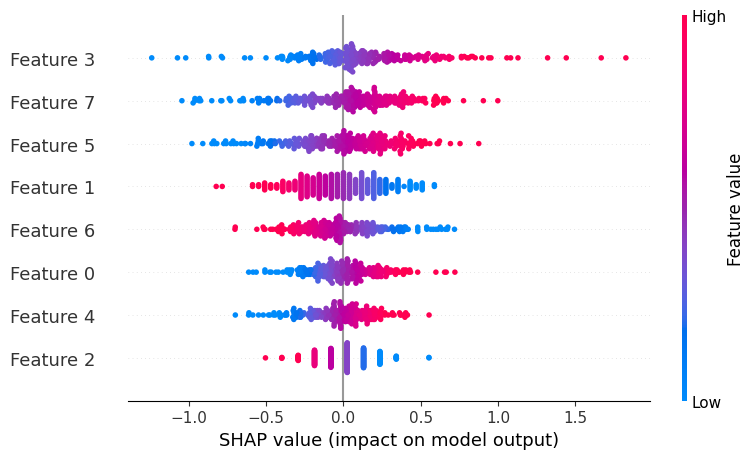

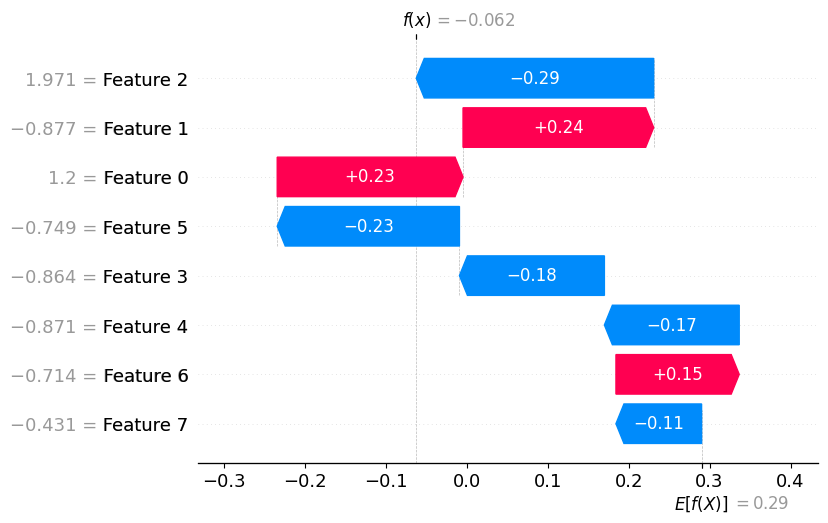

In [161]:
X = numerical_feature[["draft_wr_diff", "draft_tendency_diff", "draft_stability_diff", "elo_diff", "kda_diff", "objective_diff", "gold_total_diff", "scaling_diff"]]
y = df_final["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_scaled, y_train)

y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
y_pred = (y_pred_proba > 0.6).astype(int)

print("Feature Coefficient:\n", model.coef_)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}.")
print(f"Loss Score: {log_loss(y_test, y_pred_proba)}.")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba)}.")
print(f"Matrix Confusion: {confusion_matrix(y_test, y_pred)}.")
print(f"f1 Score: {f1_score(y_test, y_pred)}.")

explainer = shap.LinearExplainer(model, X_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled)
shap.plots.waterfall(shap_values[0])

### Experiment 1 - With and Without Draft Intelligence

**Without Draft Winrate**

Feature Coefficient:
 [[-0.26804492 -0.16774504  0.32532151  0.200377    0.34354558 -0.35739718
   0.47263203]]
Accuracy Score: 0.6459143968871596.
Loss Score: 0.6144363134619006.
ROC-AUC Score: 0.7185828877005348.
Matrix Confusion: [[76 45]
 [46 90]].
f1 Score: 0.6642066420664207.


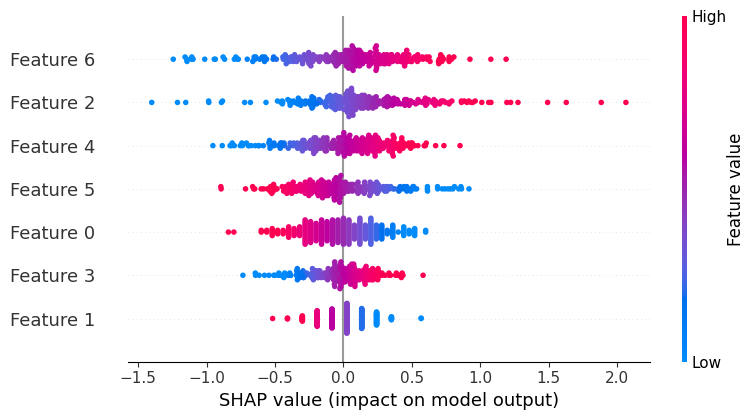

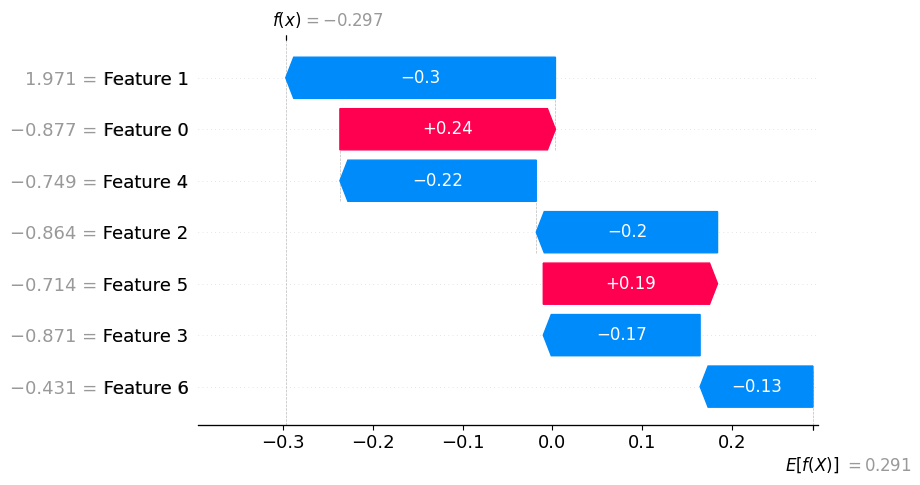

In [165]:
X = numerical_feature[["draft_tendency_diff", "draft_stability_diff", "elo_diff", "kda_diff", "objective_diff", "gold_total_diff", "scaling_diff"]]
y = df_final["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_scaled, y_train)

y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
y_pred = (y_pred_proba > 0.6).astype(int)

print("Feature Coefficient:\n", model.coef_)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}.")
print(f"Loss Score: {log_loss(y_test, y_pred_proba)}.")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba)}.")
print(f"Matrix Confusion: {confusion_matrix(y_test, y_pred)}.")
print(f"f1 Score: {f1_score(y_test, y_pred)}.")

explainer = shap.LinearExplainer(model, X_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled)
shap.plots.waterfall(shap_values[0])


**Without Draft Tendency**

Feature Coefficient:
 [[ 0.19028196 -0.12606314  0.28328954  0.15913493  0.3784099  -0.30098918
   0.43578611]]
Accuracy Score: 0.6653696498054474.
Loss Score: 0.5885544725259613.
ROC-AUC Score: 0.7437712688381137.
Matrix Confusion: [[75 46]
 [40 96]].
f1 Score: 0.6906474820143885.


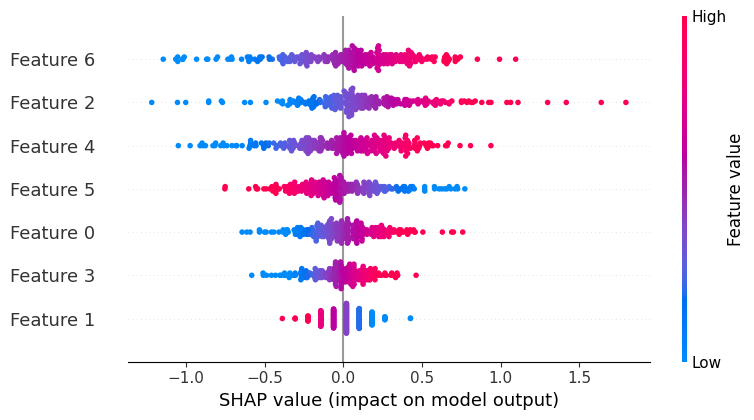

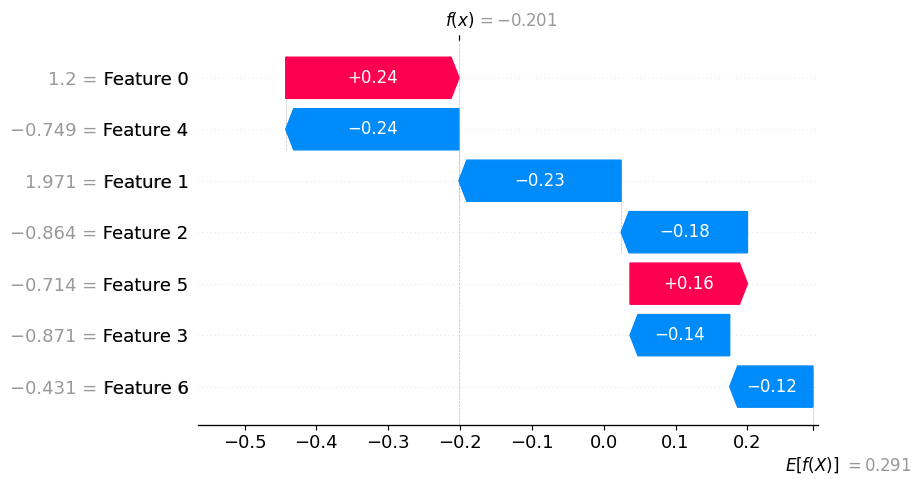

In [166]:
X = numerical_feature[["draft_wr_diff", "draft_stability_diff", "elo_diff", "kda_diff", "objective_diff", "gold_total_diff", "scaling_diff"]]
y = df_final["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_scaled, y_train)

y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
y_pred = (y_pred_proba > 0.6).astype(int)

print("Feature Coefficient:\n", model.coef_)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}.")
print(f"Loss Score: {log_loss(y_test, y_pred_proba)}.")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba)}.")
print(f"Matrix Confusion: {confusion_matrix(y_test, y_pred)}.")
print(f"f1 Score: {f1_score(y_test, y_pred)}.")

explainer = shap.LinearExplainer(model, X_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled)
shap.plots.waterfall(shap_values[0])


**Without Draft Stability**

Feature Coefficient:
 [[ 0.18489919 -0.23841735  0.27533784  0.18760512  0.36740027 -0.28323262
   0.40337104]]
Accuracy Score: 0.642023346303502.
Loss Score: 0.6015131819285341.
ROC-AUC Score: 0.7281234807972775.
Matrix Confusion: [[75 46]
 [46 90]].
f1 Score: 0.6617647058823529.


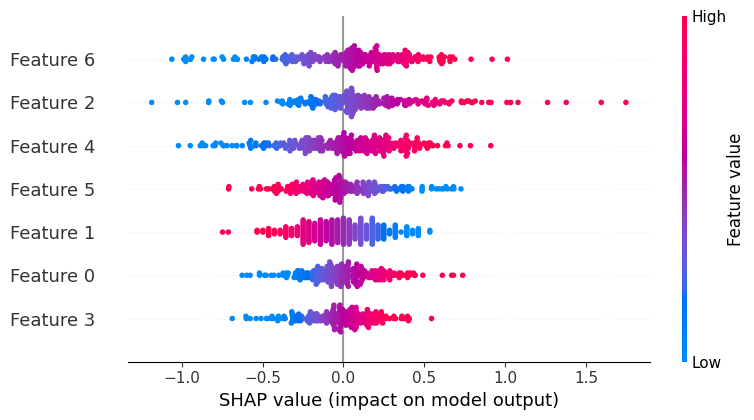

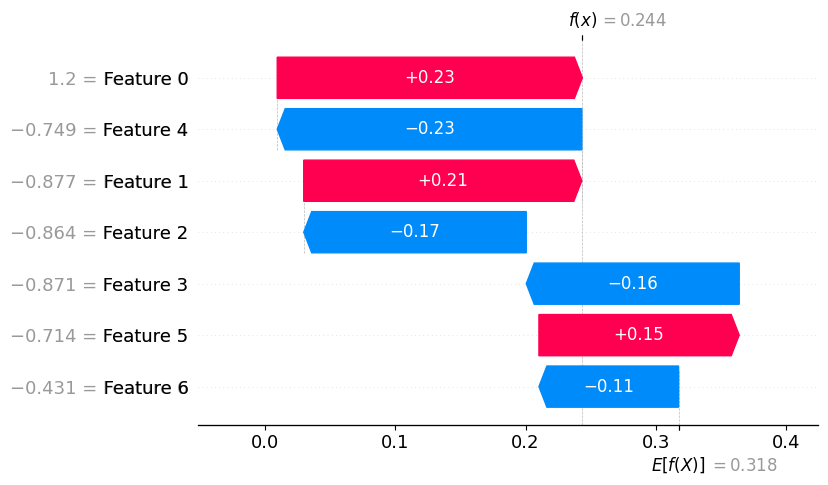

In [167]:
X = numerical_feature[["draft_wr_diff", "draft_tendency_diff", "elo_diff", "kda_diff", "objective_diff", "gold_total_diff", "scaling_diff"]]
y = df_final["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_scaled, y_train)

y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
y_pred = (y_pred_proba > 0.6).astype(int)

print("Feature Coefficient:\n", model.coef_)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}.")
print(f"Loss Score: {log_loss(y_test, y_pred_proba)}.")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba)}.")
print(f"Matrix Confusion: {confusion_matrix(y_test, y_pred)}.")
print(f"f1 Score: {f1_score(y_test, y_pred)}.")

explainer = shap.LinearExplainer(model, X_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled)
shap.plots.waterfall(shap_values[0])

### Experiment 2 - Without Elo Difference

Feature Coefficient:
 [[ 0.2291643  -0.25652952 -0.1451281   0.201004    0.45290032 -0.19364991
   0.30856485]]
Accuracy Score: 0.5953307392996109.
Loss Score: 0.6119453315056789.
ROC-AUC Score: 0.6986509479824987.
Matrix Confusion: [[74 47]
 [57 79]].
f1 Score: 0.6030534351145038.


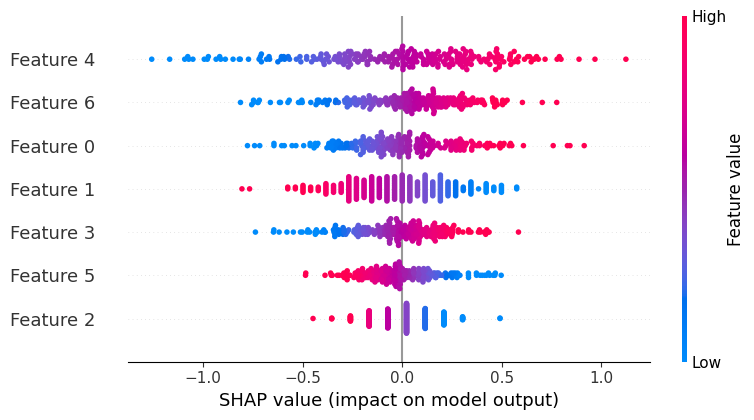

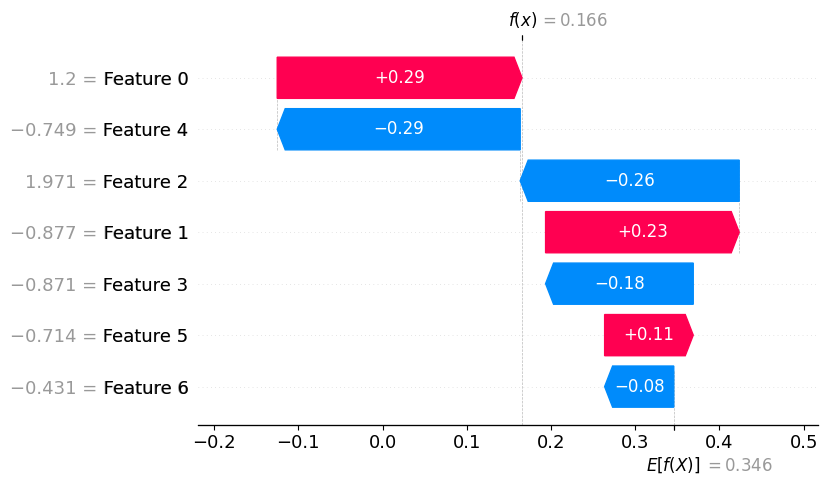

In [168]:
X = numerical_feature[["draft_wr_diff", "draft_tendency_diff", "draft_stability_diff", "kda_diff", "objective_diff", "gold_total_diff", "scaling_diff"]]
y = df_final["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_scaled, y_train)

y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
y_pred = (y_pred_proba > 0.6).astype(int)

print("Feature Coefficient:\n", model.coef_)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}.")
print(f"Loss Score: {log_loss(y_test, y_pred_proba)}.")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba)}.")
print(f"Matrix Confusion: {confusion_matrix(y_test, y_pred)}.")
print(f"f1 Score: {f1_score(y_test, y_pred)}.")

explainer = shap.LinearExplainer(model, X_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled)
shap.plots.waterfall(shap_values[0])

### Experiment 3 - Without Total Gold Diff and Scaling Diff

**Without Total Gold Difference**

Feature Coefficient:
 [[ 0.1850532  -0.26274823 -0.16419123  0.28488748  0.17846995  0.35077281
   0.13333023]]
Accuracy Score: 0.6536964980544747.
Loss Score: 0.5988787466387693.
ROC-AUC Score: 0.7301895964997569.
Matrix Confusion: [[76 45]
 [44 92]].
f1 Score: 0.673992673992674.


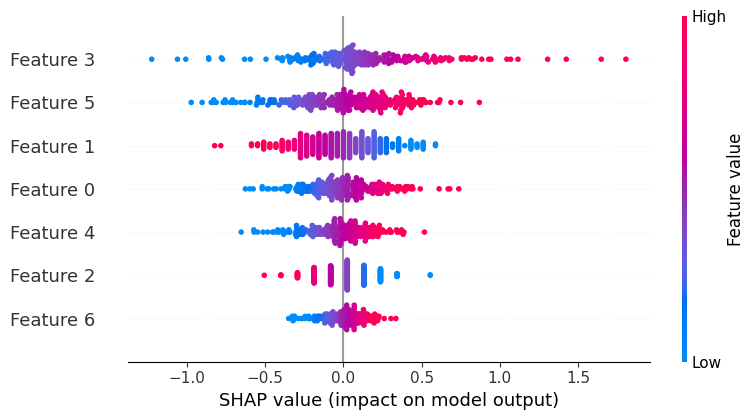

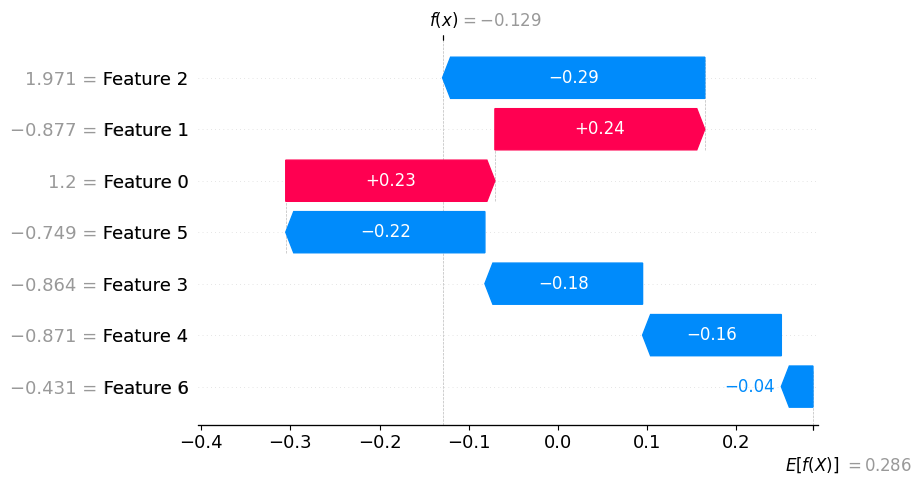

In [173]:
X = numerical_feature[["draft_wr_diff", "draft_tendency_diff", "draft_stability_diff", "elo_diff", "kda_diff", "objective_diff", "scaling_diff"]]
y = df_final["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_scaled, y_train)

y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
y_pred = (y_pred_proba > 0.6).astype(int)

print("Feature Coefficient:\n", model.coef_)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}.")
print(f"Loss Score: {log_loss(y_test, y_pred_proba)}.")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba)}.")
print(f"Matrix Confusion: {confusion_matrix(y_test, y_pred)}.")
print(f"f1 Score: {f1_score(y_test, y_pred)}.")

explainer = shap.LinearExplainer(model, X_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled)
shap.plots.waterfall(shap_values[0])

**Without Scaling Difference**

Feature Coefficient:
 [[ 0.18652745 -0.26374589 -0.16451479  0.28307799  0.18432247  0.37385235
   0.09901865]]
Accuracy Score: 0.6498054474708171.
Loss Score: 0.5994830826062137.
ROC-AUC Score: 0.730068060281964.
Matrix Confusion: [[76 45]
 [45 91]].
f1 Score: 0.6691176470588235.


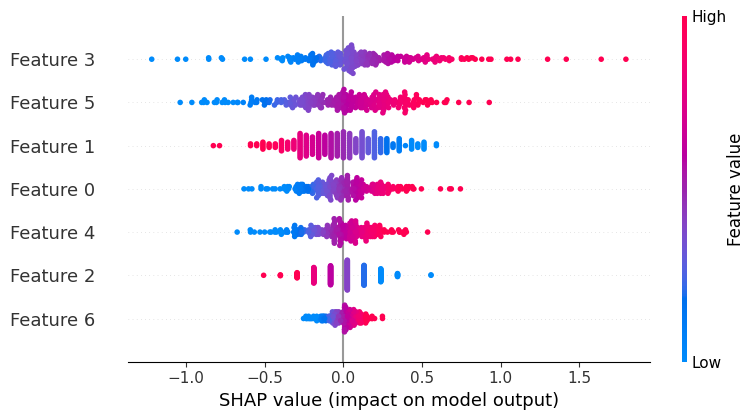

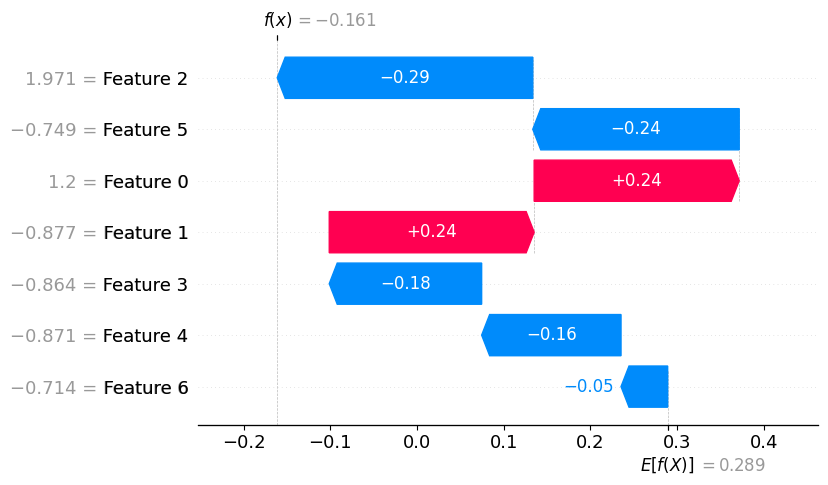

In [174]:
X = numerical_feature[["draft_wr_diff", "draft_tendency_diff", "draft_stability_diff", "elo_diff", "kda_diff", "objective_diff", "gold_total_diff"]]
y = df_final["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_scaled, y_train)

y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
y_pred = (y_pred_proba > 0.6).astype(int)

print("Feature Coefficient:\n", model.coef_)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}.")
print(f"Loss Score: {log_loss(y_test, y_pred_proba)}.")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba)}.")
print(f"Matrix Confusion: {confusion_matrix(y_test, y_pred)}.")
print(f"f1 Score: {f1_score(y_test, y_pred)}.")

explainer = shap.LinearExplainer(model, X_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled)
shap.plots.waterfall(shap_values[0])

**Insight**
- Model interpretability get better without draft tendency feature that might be redundant.
- Elo and economy related feature are dominated model predict decision, then model struggle to predict on comeback scenario games.

Logistic
[[ 0.19028196 -0.12606314  0.28328954  0.15913493  0.3784099  -0.30098918
   0.43578611]]


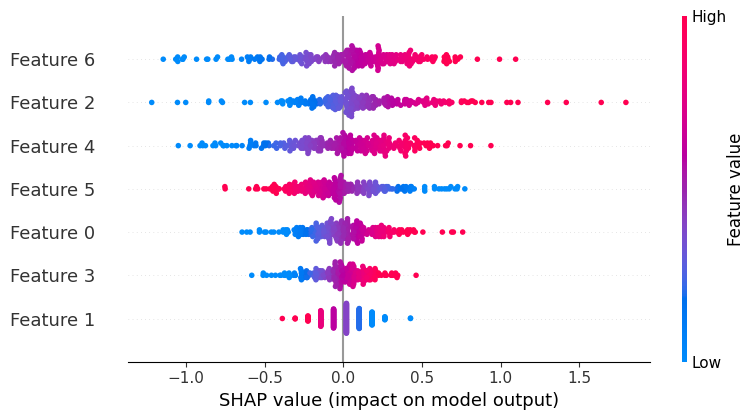

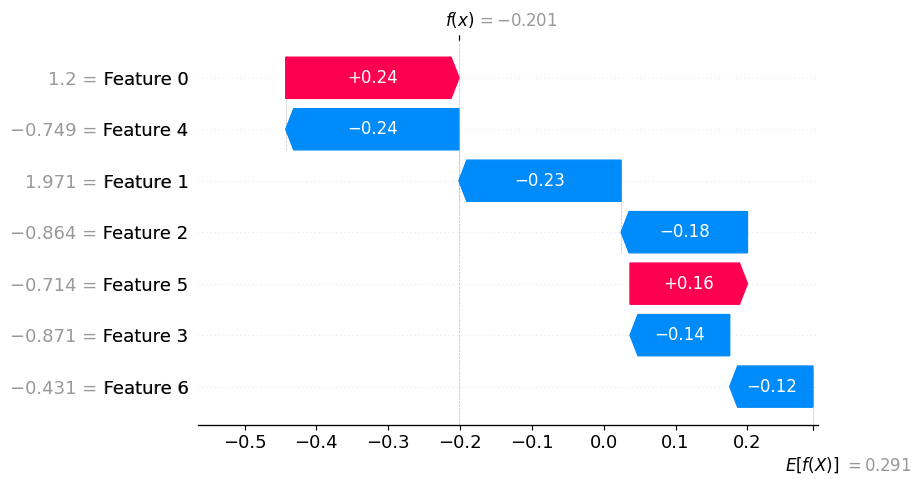

RF
                feature  importance
2              elo_diff    0.162994
4        objective_diff    0.162315
6          scaling_diff    0.161458
5       gold_total_diff    0.158636
3              kda_diff    0.150844
0         draft_wr_diff    0.130472
1  draft_stability_diff    0.073280
RF
not list
(257, 7, 2)


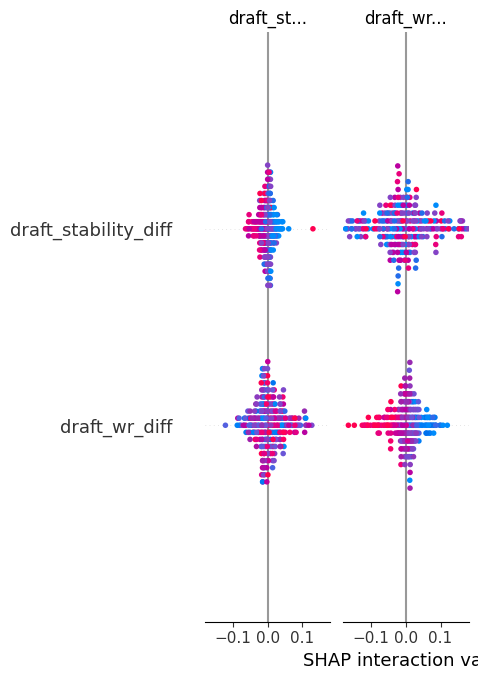

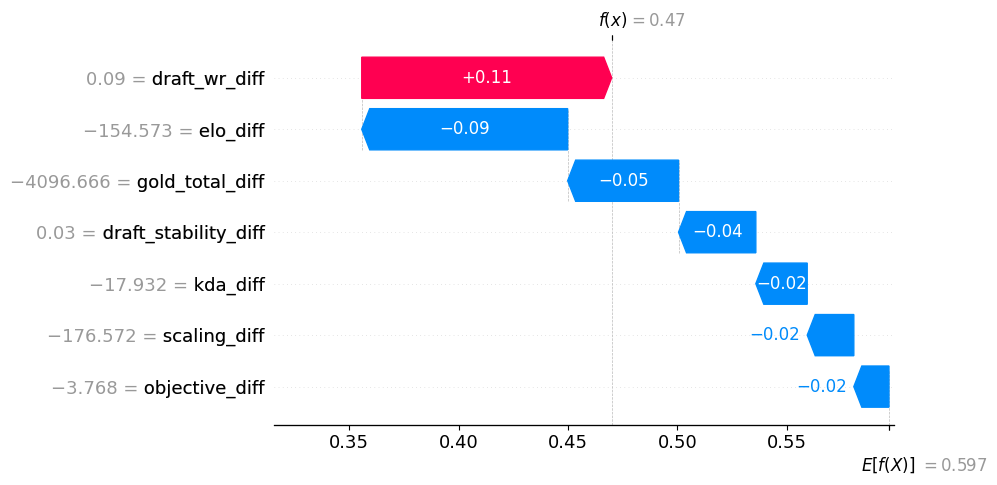

XGB
                feature  importance
4        objective_diff    0.188937
2              elo_diff    0.148261
5       gold_total_diff    0.145801
3              kda_diff    0.145251
6          scaling_diff    0.131312
0         draft_wr_diff    0.129205
1  draft_stability_diff    0.111233
XGB
not list
(257, 7)


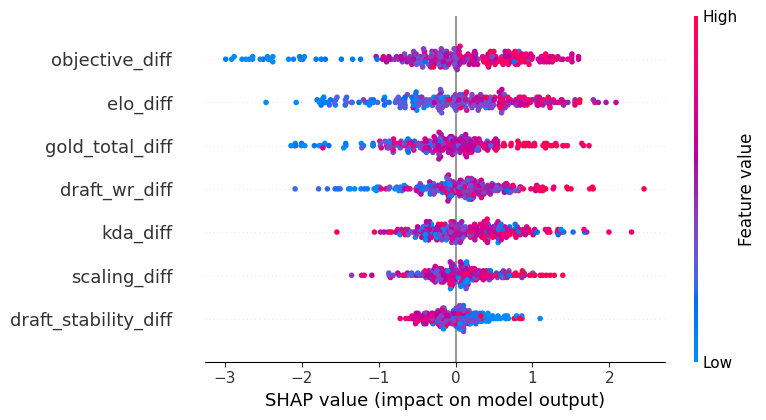

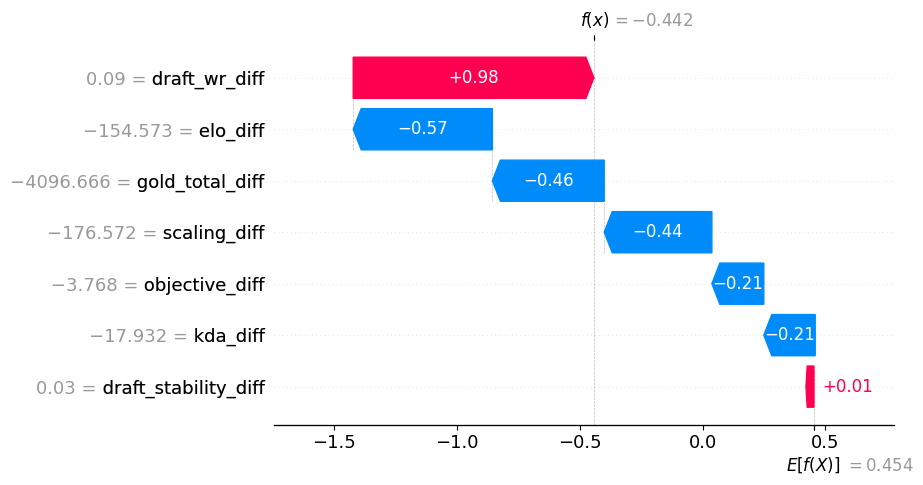

,model,Loss,Acc,ROC_AUC,F1,CM
0,LogisticRegression(),0.588554,0.603113,0.743771,0.474227,"[[109, 12], [90, 46]]"
1,"(DecisionTreeClassifier(max_features='sqrt', r...",0.782104,0.587549,0.675589,0.470000,"[[104, 17], [89, 47]]"
2,"XGBClassifier(base_score=None, booster=None, c...",0.834123,0.645914,0.698681,0.640316,"[[85, 36], [55, 81]]"


In [175]:
X = numerical_feature[["draft_wr_diff", "draft_stability_diff", "elo_diff", "kda_diff", "objective_diff", "gold_total_diff", "scaling_diff"]]
y = df_final["label"].astype(int)

result = []

model = {
    "Logistic": LogisticRegression(),
    "RF": RandomForestClassifier(),
    "XGB": XGBClassifier()
}

for name, model, in model.items():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    if name == "Logistic":
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    model.fit(X_train, y_train)

    if name == "RF" or name == "XGB":
        # Feature Importance
        importance = model.feature_importances_

        feat_imp = pd.DataFrame({
            "feature": X.columns,
            "importance": importance
        }).sort_values(by="importance", ascending=False)
        print(name)
        print(feat_imp)
    
    if name == "Logistic":
        print(name)
        print(model.coef_)
        explainer = shap.LinearExplainer(model, X_train)
        shap_values = explainer(X_test)
        shap.summary_plot(shap_values, X_test)
        shap.plots.waterfall(shap_values[0])

    if name == "RF":
        print(name)
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_test, check_additivity=False)
        print(len(shap_values) if isinstance(shap_values, list) else "not list")
        print(shap_values.shape)
            
        shap.summary_plot(shap_values, X_test)
        shap.plots.waterfall(shap_values[0, :, 1])
    
    if name == "XGB":
        print(name)
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_test, check_additivity=False)
        print(len(shap_values) if isinstance(shap_values, list) else "not list")
        print(shap_values.shape)
            
        shap.summary_plot(shap_values, X_test)
        shap.plots.waterfall(shap_values[0])
    
    y_pred_probability = model.predict_proba(X_test)[:,1]
    y_pred = (y_pred_probability > 0.75).astype(int)    

    result.append({
        "model": model,
        "Loss": log_loss(y_test, y_pred_probability),
        "Acc": accuracy_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_pred_probability),
        "F1": f1_score(y_test, y_pred),
        "CM": confusion_matrix(y_test, y_pred)})

pd.DataFrame(result)

Best F1 Score: 0.7428571428571429.
Best threshold: 0.5040816326530613.
Accuracy Score: 0.6186770428015564.
Loss Score: 0.5885544725259613.
ROC-AUC Score: 0.7437712688381137.
Confusion matrix : [[97 24]
 [74 62]].


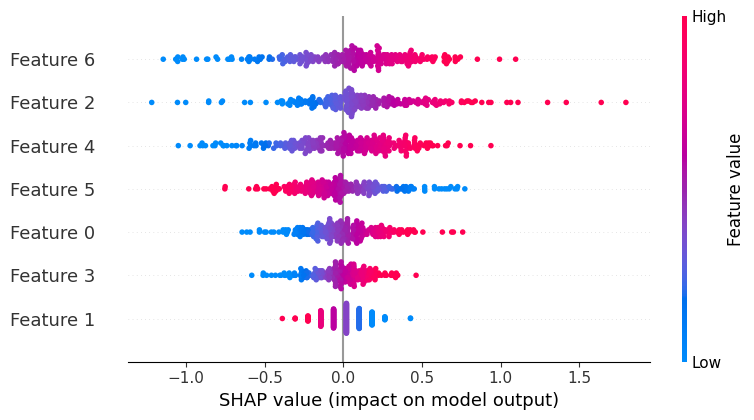

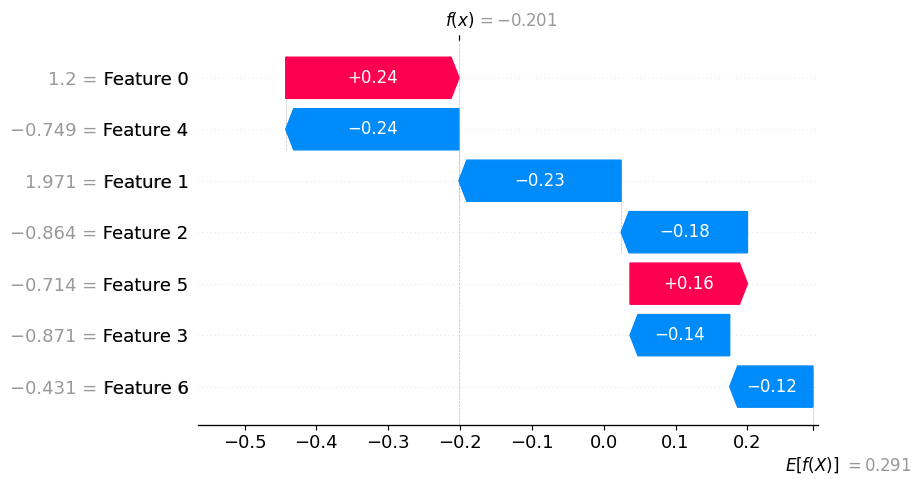

In [179]:
X = numerical_feature[["draft_wr_diff", "draft_stability_diff", "elo_diff", "kda_diff", "objective_diff", "gold_total_diff", "scaling_diff"]]
y = df_final["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_scaled, y_train)

y_proba = model.predict_proba(X_test_scaled)[:,1]
y_pred = (y_proba > 0.5).astype(int)

threshold = np.linspace(0.5, 0.7, 50)

best_f1 = 0

for t in threshold:
    y_pred = (y_proba > t).astype(int)
    f1 = f1_score(y_test, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"Best F1 Score: {best_f1}.")
print(f"Best threshold: {best_t}.")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}.")
print(f"Loss Score: {log_loss(y_test, y_proba)}.")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba)}.")
print(f"Confusion matrix : {confusion_matrix(y_test, y_pred)}.")

explainer = shap.LinearExplainer(model, X_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled)
shap.plots.waterfall(shap_values[0])

In [182]:
coef = model.coef_[0]
for f, c in zip(X.columns, coef):
    print(f"{f}: {c}")

draft_wr_diff: 0.1902819592560131
draft_stability_diff: -0.12606314300636795
elo_diff: 0.28328954113836424
kda_diff: 0.15913492931120918
objective_diff: 0.37840990307667766
gold_total_diff: -0.30098917510408013
scaling_diff: 0.4357861125893026


In [ ]:
sample = [[0.2, -0.1, 0.1, 50, 1600, 500, -1000, -0.3, 0.1]]

proba = model.predict_proba(sample)[0][1]
print(f"probalilitas home menang: {proba}")

probalilitas home menang: 0.9875894079433689


In [181]:
df_eval = X_test.copy()
df_eval["y_true"] = y_test
df_eval["y_pred"] = y_pred
df_eval["proba"] = y_proba
fn = df_eval[(df_eval["y_true"] == 0) & (df_eval["y_pred"] == 0)]
fn.sort_values(by="proba", ascending=True)

,draft_wr_diff,draft_stability_diff,elo_diff,kda_diff,objective_diff,gold_total_diff,scaling_diff,y_true,y_pred,proba
1142,-0.130,0.03,-618.745198,-31.834,-11.866,-9566.666,-734.9340,0,0,0.089310
1196,-0.034,0.05,-233.783851,-64.100,-12.600,-15250.000,-1241.6600,0,0,0.108812
1156,-0.134,0.04,-228.324309,-43.966,-12.666,-14606.666,-1063.9320,0,0,0.116498
1031,-0.032,0.01,-618.209729,-37.066,-10.000,-9970.000,-802.5660,0,0,0.136046
1197,-0.034,0.01,-216.115952,-71.600,-14.132,-15466.668,-1139.4660,0,0,0.141227
...,...,...,...,...,...,...,...,...,...,...
1038,0.110,0.02,0.000000,7.875,2.125,1949.500,211.8475,0,0,0.684738
1060,-0.018,0.02,41.780252,8.234,7.434,7103.332,444.4220,0,0,0.690164
1057,0.092,0.00,-53.847643,9.500,1.534,3510.002,318.5340,0,0,0.690719
1195,0.032,0.00,78.614568,16.248,2.128,2305.334,143.6520,0,0,0.695921


## Insights

**Error Analysis**

- Model struggle on close match like small draft winrate difference and elo difference, resulting in prediction uncertainty.
- Model is overconfident on scaling, elo and objective difference then misclassification when comeback scenario.

**Segment Analysis**

- Model is accurately predict the match with draft strength and power strength gap are huge rather than a tight gap strength match.
- Elo and economy related features are overshadowing draft intelligence feature.